# CCF DNN + NSGA-II Template

현재 CCF 데이터(`axis_shortedge_ccf_summary.csv`)를 대상으로 `3입력 4출력` DNN surrogate를 만들고,
제약함수 없이 `2목적 NSGA-II`를 수행하는 템플릿이다.

입력:
- `magnet_thickness_mm`
- `magnet_length_mm`
- `v_angle_deg`

출력:
- `loaded_torque_mean`
- `loaded_torque_ripple_pct`
- `cogging_torque_pkpk`
- `loaded_force_max`

목적함수:
- `f1 = - loaded_torque_mean`
- `f2 = loaded_torque_ripple_pct`

주의:
- 현재 데이터 수는 `15점`뿐이므로, 이 노트북은 우선 exploratory surrogate 용도로 보는 것이 맞다.
- 최종 후보는 반드시 추가 FEM 검증이 필요하다.

In [7]:
import sys
import tensorflow as tf

print(sys.executable)
print(tf.__version__)

/Users/dohyunkim/Documents/Window/.venv/bin/python
2.21.0


In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import Model
from tensorflow.keras.layers import Input, Dense

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import r2_score

from pathlib import Path

In [9]:
csv_path = Path('/Users/dohyunkim/Documents/Window/femm_output_v_ipm_m19_axis_shortedge_ccf/axis_shortedge_ccf_summary.csv')
df = pd.read_csv(csv_path)
df = df[df['completed_design'] == 1].copy()
df

,run,coded_thickness,coded_length,coded_v_angle,magnet_thickness_mm,magnet_length_mm,v_angle_deg,v_included_angle_deg,completed_design,loaded_torque_mean,loaded_torque_min,loaded_torque_max,loaded_torque_pkpk,loaded_torque_ripple_pct,cogging_torque_pkpk,loaded_force_max,loaded_force_mean
0,1,-1,-1,-1,3,13.0,45.0,90,1,13.929401,11.313513,16.583047,5.269534,37.830297,0.001604,1190.301253,800.259809
1,2,-1,-1,1,3,13.0,60.0,120,1,24.586555,20.902239,29.418220,8.515981,34.636739,0.006627,1203.567476,864.955938
2,3,-1,1,-1,3,16.0,45.0,90,1,26.032086,22.416263,30.667442,8.251179,31.696187,0.044483,1077.922839,772.784556
3,4,-1,1,1,3,16.0,60.0,120,1,40.168085,34.437280,45.562743,11.125464,27.697272,0.185937,1087.528629,726.906964
4,5,1,-1,-1,5,13.0,45.0,90,1,19.125020,15.463693,23.726187,8.262493,43.202535,0.011596,1047.343322,754.719505
5,6,1,-1,1,5,13.0,60.0,120,1,31.987111,27.653433,36.383878,8.730445,27.293634,0.008803,1032.068430,716.894788
6,7,1,1,-1,5,16.0,45.0,90,1,34.774458,29.067066,41.366603,12.299537,35.369456,0.215795,1042.194010,635.780068
7,8,1,1,1,5,16.0,60.0,120,1,50.729518,45.399014,56.606964,11.207950,22.093547,0.378221,841.032027,575.927429
8,9,-1,0,0,3,14.5,52.5,105,1,26.903578,22.846132,31.542495,8.696363,32.324188,0.016029,1123.411897,811.082354
9,10,1,0,0,5,14.5,52.5,105,1,35.470886,30.994863,40.105668,9.110805,25.685303,0.021345,1016.565695,648.399132


## Input / Output Table

In [10]:
input_cols = [
    'magnet_thickness_mm',
    'magnet_length_mm',
    'v_angle_deg',
]

output_cols = [
    'loaded_torque_mean',
    'loaded_torque_ripple_pct',
    'cogging_torque_pkpk',
    'loaded_force_max',
]

X = df[input_cols].copy()
Y = df[output_cols].copy()

display(X)
display(Y)

,magnet_thickness_mm,magnet_length_mm,v_angle_deg
0,3,13.0,45.0
1,3,13.0,60.0
2,3,16.0,45.0
3,3,16.0,60.0
4,5,13.0,45.0
5,5,13.0,60.0
6,5,16.0,45.0
7,5,16.0,60.0
8,3,14.5,52.5
9,5,14.5,52.5


,loaded_torque_mean,loaded_torque_ripple_pct,cogging_torque_pkpk,loaded_force_max
0,13.929401,37.830297,0.001604,1190.301253
1,24.586555,34.636739,0.006627,1203.567476
2,26.032086,31.696187,0.044483,1077.922839
3,40.168085,27.697272,0.185937,1087.528629
4,19.125020,43.202535,0.011596,1047.343322
5,31.987111,27.293634,0.008803,1032.068430
6,34.774458,35.369456,0.215795,1042.194010
7,50.729518,22.093547,0.378221,841.032027
8,26.903578,32.324188,0.016029,1123.411897
9,35.470886,25.685303,0.021345,1016.565695


In [11]:
df[input_cols + output_cols].corr(method='spearman')

,magnet_thickness_mm,magnet_length_mm,v_angle_deg,loaded_torque_mean,loaded_torque_ripple_pct,cogging_torque_pkpk,loaded_force_max
magnet_thickness_mm,1.000000,0.000000,0.000000,0.264575,-0.245677,0.264575,-0.869318
magnet_length_mm,0.000000,1.000000,0.000000,0.718132,-0.472456,0.907115,-0.340168
v_angle_deg,0.000000,0.000000,1.000000,0.604743,-0.623641,0.094491,-0.056695
loaded_torque_mean,0.264575,0.718132,0.604743,1.000000,-0.821429,0.771429,-0.528571
loaded_torque_ripple_pct,-0.245677,-0.472456,-0.623641,-0.821429,1.000000,-0.417857,0.571429
cogging_torque_pkpk,0.264575,0.907115,0.094491,0.771429,-0.417857,1.000000,-0.492857
loaded_force_max,-0.869318,-0.340168,-0.056695,-0.528571,0.571429,-0.492857,1.000000


## Scaling

In [12]:
scaler_input = MinMaxScaler()
scaler_output = MinMaxScaler()

X_scaled = scaler_input.fit_transform(X)
Y_scaled = scaler_output.fit_transform(Y)

X_scaled.shape, Y_scaled.shape

((15, 3), (15, 4))

## DNN Surrogate

현재는 데이터가 작으므로, 일단 전체 데이터로 fit하는 exploratory surrogate로 둔다.

In [13]:
class CCFModel(Model):
    def __init__(self):
        super().__init__()
        self.l1 = Dense(128, activation='relu', kernel_initializer='uniform')
        self.l2 = Dense(64, activation='relu')
        self.l3 = Dense(32, activation='relu')
        self.l4 = Dense(4, activation='linear')

    def call(self, x_input):
        x = self.l1(x_input)
        x = self.l2(x)
        x = self.l3(x)
        y = self.l4(x)
        return y

model = CCFModel()
dummy_input = Input((3,))
model(dummy_input)

<KerasTensor shape=(None, 4), dtype=float32, sparse=False, ragged=False, name=keras_tensor_2>

In [14]:
model.compile(loss='mae', optimizer='adam', metrics=['mse'])

In [15]:
history = model.fit(
    X_scaled,
    Y_scaled,
    batch_size=8,
    epochs=300,
    verbose=1
)

Epoch 1/300
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - loss: 0.4302 - mse: 0.2712
Epoch 2/300
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.4124 - mse: 0.2536
Epoch 3/300
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.4009 - mse: 0.2409
Epoch 4/300
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.3897 - mse: 0.2277
Epoch 5/300
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.3756 - mse: 0.2132
Epoch 6/300
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.3591 - mse: 0.1967
Epoch 7/300
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.3411 - mse: 0.1801
Epoch 8/300
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.3220 - mse: 0.1627
Epoch 9/300
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.3044 - mse: 0.1440
Epoch 10/300
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.2862 - mse: 0.1269
Epoch 11/300
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.2689 - mse: 0.1120
Epoch 12/300
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.2490 - mse: 0.0982
Epoch 13/300
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/ste

In [16]:
Y_pred_scaled = model.predict(X_scaled)
Y_pred = scaler_output.inverse_transform(Y_pred_scaled)

for i, col in enumerate(output_cols):
    r2 = r2_score(Y.iloc[:, i], Y_pred[:, i])
    print(col, 'R2 =', round(r2, 4))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
loaded_torque_mean R2 = 0.9998
loaded_torque_ripple_pct R2 = 0.9995
cogging_torque_pkpk R2 = 0.9978
loaded_force_max R2 = 0.998


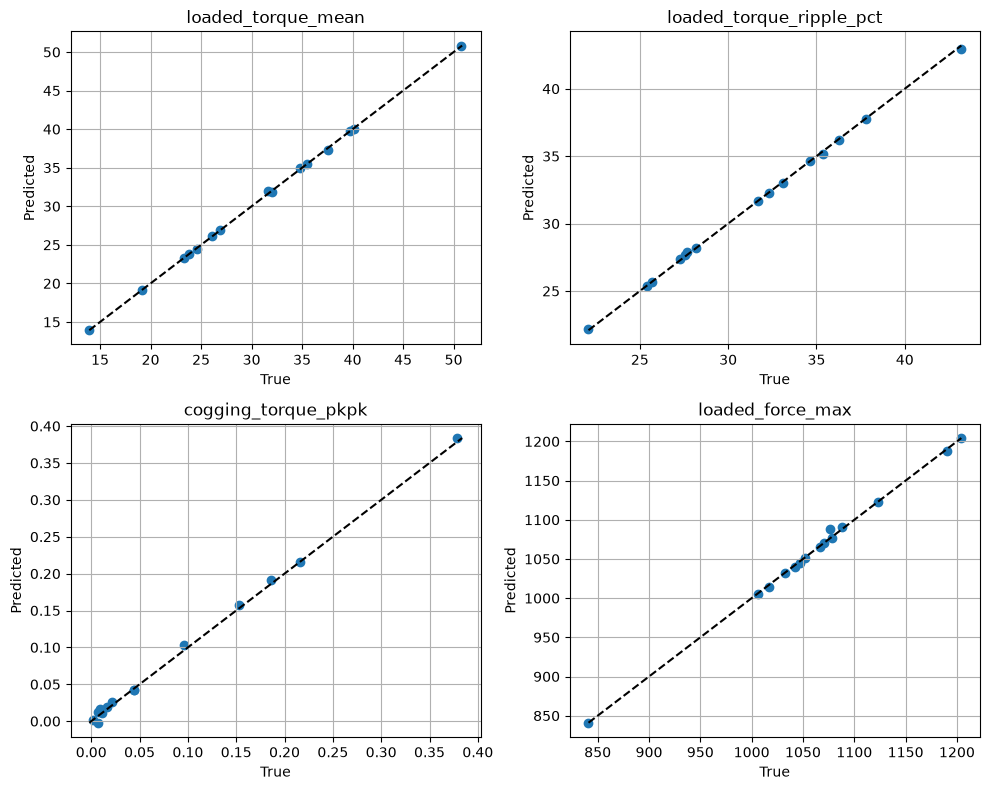

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.ravel()

for i, col in enumerate(output_cols):
    axes[i].scatter(Y.iloc[:, i], Y_pred[:, i])
    lo = min(Y.iloc[:, i].min(), Y_pred[:, i].min())
    hi = max(Y.iloc[:, i].max(), Y_pred[:, i].max())
    axes[i].plot([lo, hi], [lo, hi], 'k--')
    axes[i].set_title(col)
    axes[i].set_xlabel('True')
    axes[i].set_ylabel('Predicted')
    axes[i].grid(True)

plt.tight_layout()
plt.show()

## Surrogate Output Helpers

In [18]:
def predict_outputs_scaled(arr_scaled):
    pred_scaled = model.predict(arr_scaled, verbose=0)
    return scaler_output.inverse_transform(pred_scaled)

def torque_mean(arr_scaled):
    return predict_outputs_scaled(arr_scaled)[:, 0]

def torque_ripple(arr_scaled):
    return predict_outputs_scaled(arr_scaled)[:, 1]

def cogging_pp(arr_scaled):
    return predict_outputs_scaled(arr_scaled)[:, 2]

def force_max(arr_scaled):
    return predict_outputs_scaled(arr_scaled)[:, 3]

## NSGA-II

현재는 제약함수 없이 `2목적`만 둔다.

- `f1 = - torque_mean`
- `f2 = torque_ripple`

In [19]:
# !pip install pymoo

In [20]:
import pymoo.gradient.toolbox as anp
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.core.problem import Problem
from pymoo.optimize import minimize
from pymoo.visualization.scatter import Scatter

In [21]:
minimum = np.array([0.0, 0.0, 0.0])
maximum = np.array([1.0, 1.0, 1.0])

In [22]:
class CCFProblem(Problem):
    def __init__(self):
        super().__init__(n_var=3, n_obj=2, n_ieq_constr=0, vtype=float)
        self.xl = minimum
        self.xu = maximum

    def _evaluate(self, x, out, *args, **kwargs):
        f1 = - torque_mean(x)
        f2 = torque_ripple(x)
        out['F'] = anp.column_stack([f1, f2])

In [23]:
problem = CCFProblem()
algorithm = NSGA2(pop_size=300)

res = minimize(
    problem,
    algorithm,
    ('n_gen', 80),
    seed=1,
    verbose=True
)

res.F[:5]

n_gen  |  n_eval  | n_nds  |      eps      |   indicator  
     1 |      300 |      2 |             - |             -
     2 |      600 |      1 |  0.2073974609 |         ideal
     3 |      900 |      1 |  1.4997100830 |         ideal
     4 |     1200 |      1 |  0.000000E+00 |             f
     5 |     1500 |      2 |  1.1435237860 |         ideal
     6 |     1800 |      1 |  0.4870834351 |         ideal
     7 |     2100 |      1 |  0.1434249878 |         ideal
     8 |     2400 |      1 |  0.000000E+00 |             f
     9 |     2700 |      1 |  0.0512123108 |         ideal
    10 |     3000 |      1 |  0.000000E+00 |             f
    11 |     3300 |      2 |  6.564706E+01 |         ideal
    12 |     3600 |      2 |  1.396774E+01 |         ideal
    13 |     3900 |      2 |  1.7982832618 |         ideal
    14 |     4200 |      1 |  0.0026245117 |         nadir
    15 |     4500 |      1 |  0.0019161299 |             f
    16 |     4800 |      1 |  0.0021280618 |            

array([[-50.84148788,  22.20195961],
       [-50.84148788,  22.20195961],
       [-50.84148788,  22.20195961],
       [-50.84148788,  22.20195961],
       [-50.84148788,  22.20195961]])

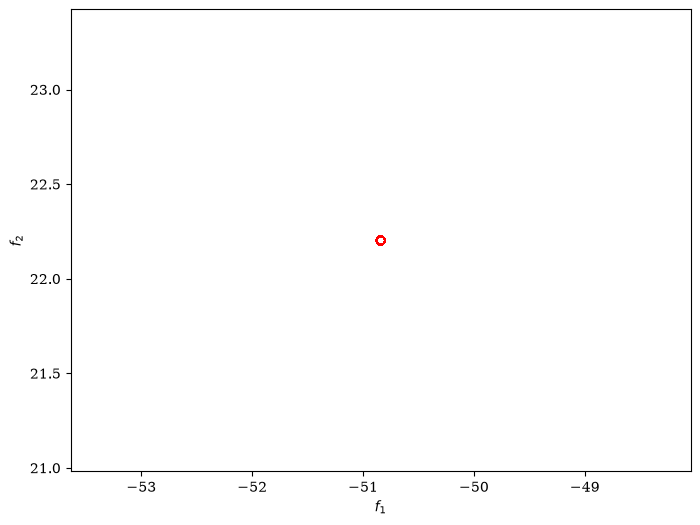

In [24]:
plot = Scatter()
plot.add(res.F, facecolor='none', edgecolor='red')
plot.show()

In [25]:
X_pareto_scaled = res.X
X_pareto = scaler_input.inverse_transform(X_pareto_scaled)
Y_pareto = predict_outputs_scaled(X_pareto_scaled)

pareto_df = pd.DataFrame(X_pareto, columns=input_cols)
for i, col in enumerate(output_cols):
    pareto_df[col] = Y_pareto[:, i]

pareto_df['objective_neg_torque'] = res.F[:, 0]
pareto_df['objective_ripple'] = res.F[:, 1]
pareto_df.head()

,magnet_thickness_mm,magnet_length_mm,v_angle_deg,loaded_torque_mean,loaded_torque_ripple_pct,cogging_torque_pkpk,loaded_force_max,objective_neg_torque,objective_ripple
0,5.0,16.0,59.999999,50.841488,22.20196,0.383742,841.169495,-50.841488,22.20196
1,5.0,16.0,59.999998,50.841488,22.20196,0.383742,841.169495,-50.841488,22.20196
2,5.0,16.0,59.999999,50.841488,22.20196,0.383742,841.169495,-50.841488,22.20196
3,5.0,16.0,59.999999,50.841488,22.20196,0.383742,841.169495,-50.841488,22.20196
4,5.0,16.0,59.999999,50.841488,22.20196,0.383742,841.169495,-50.841488,22.20196


In [26]:
pareto_df.sort_values(['objective_ripple', 'loaded_torque_mean'], ascending=[True, False]).head(20)

,magnet_thickness_mm,magnet_length_mm,v_angle_deg,loaded_torque_mean,loaded_torque_ripple_pct,cogging_torque_pkpk,loaded_force_max,objective_neg_torque,objective_ripple
0,5.000000,16.0,59.999999,50.841488,22.20196,0.383742,841.169495,-50.841488,22.20196
1,5.000000,16.0,59.999998,50.841488,22.20196,0.383742,841.169495,-50.841488,22.20196
2,5.000000,16.0,59.999999,50.841488,22.20196,0.383742,841.169495,-50.841488,22.20196
3,5.000000,16.0,59.999999,50.841488,22.20196,0.383742,841.169495,-50.841488,22.20196
4,5.000000,16.0,59.999999,50.841488,22.20196,0.383742,841.169495,-50.841488,22.20196
5,5.000000,16.0,59.999999,50.841488,22.20196,0.383742,841.169495,-50.841488,22.20196
6,5.000000,16.0,59.999999,50.841488,22.20196,0.383742,841.169495,-50.841488,22.20196
7,5.000000,16.0,59.999999,50.841488,22.20196,0.383742,841.169495,-50.841488,22.20196
8,5.000000,16.0,59.999998,50.841488,22.20196,0.383742,841.169495,-50.841488,22.20196
9,5.000000,16.0,59.999998,50.841488,22.20196,0.383742,841.169495,-50.841488,22.20196


## Notes

- 현재는 제약함수를 일부러 넣지 않았다.
- 코깅과 force는 Pareto 후보를 얻은 뒤 후처리로 보는 방식이다.
- 추후 필요하면 `cogging_pp`, `force_max`를 제약 또는 추가 목적함수로 확장할 수 있다.
- 데이터가 더 쌓이면 train/validation split, k-fold, GP/RSM 비교도 권장된다.